# 🌦️ Data Exploration – Weather Vietnam

**Mục tiêu notebook:**
- Khám phá cấu trúc dataset sau preprocessing
- Kiểm tra chất lượng dữ liệu (missing, imbalance)
- Thống kê mô tả & phân phối các biến
- So sánh thời tiết giữa các tỉnh/thành phố
- Phân tích theo thời gian (trend, seasonality)
- Rút ra insights phục vụ ML/model training

---

## 0. Setup & Import

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pyspark.sql import SparkSession
import warnings

warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('✅ Libraries loaded.')

✅ Libraries loaded.


In [2]:
# ── Load dataset từ bronze parquet trên MinIO ─────────────────────────────
aws_access_key = os.getenv("AWS_ACCESS_KEY_ID", "minioadmin")
aws_secret_key = os.getenv("AWS_SECRET_ACCESS_KEY", "minioadmin123")
minio_endpoint = os.getenv("S3_ENDPOINT", "http://minio:9000")
DATA_PATH = os.getenv("BRONZE_WEATHER_PATH", "s3a://iceberg/bronze/weather_raw_parquet/")
spark_master = os.getenv("SPARK_MASTER_URL")
spark_packages = os.getenv("SPARK_JARS_PACKAGES", "").strip()

spark_builder = SparkSession.builder.appName("Weather-Data-Exploration")
if spark_master:
    spark_builder = spark_builder.master(spark_master)

if spark_packages:
    spark_builder = spark_builder \
        .config("spark.jars.packages", spark_packages) \
        .config("spark.jars.repositories", "https://repo1.maven.org/maven2")

spark = spark_builder \
    .config("spark.hadoop.fs.s3a.endpoint", minio_endpoint) \
    .config("spark.hadoop.fs.s3a.access.key", aws_access_key) \
    .config("spark.hadoop.fs.s3a.secret.key", aws_secret_key) \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false") \
    .getOrCreate()

df = spark.read.parquet(DATA_PATH).toPandas()
df['time'] = pd.to_datetime(df['time'])
print(f'✅ Loaded {len(df):,} rows × {df.shape[1]} cols')
df.head(3)

https://repo1.maven.org/maven2 added as a remote repository with the name: repo-1


:: loading settings :: url = jar:file:/opt/spark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/spark/.ivy2/cache
The jars for the packages stored in: /home/spark/.ivy2/jars
org.apache.iceberg#iceberg-spark-runtime-3.5_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-aee93a6e-2488-4b34-9ccf-cdbb102c0271;1.0
	confs: [default]
	found org.apache.iceberg#iceberg-spark-runtime-3.5_2.12;1.9.2 in central
downloading https://repo1.maven.org/maven2/org/apache/iceberg/iceberg-spark-runtime-3.5_2.12/1.9.2/iceberg-spark-runtime-3.5_2.12-1.9.2.jar ...
	[SUCCESSFUL ] org.apache.iceberg#iceberg-spark-runtime-3.5_2.12;1.9.2!iceberg-spark-runtime-3.5_2.12.jar (8026ms)
:: resolution report :: resolve 1217ms :: artifacts dl 8030ms
	:: modules in use:
	org.apache.iceberg#iceberg-spark-runtime-3.5_2.12;1.9.2 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|

TypeError: 'JavaPackage' object is not callable

---
## 1. Khám Phá Cấu Trúc Dataset
### 1.1 Schema tổng quát

In [ ]:
print('=== SHAPE ===')
print(f'Rows: {df.shape[0]:,}  |  Cols: {df.shape[1]}')

print('\n=== DTYPES ===')
print(df.dtypes.to_string())

print('\n=== SAMPLE (5 rows) ===')
df.sample(5, random_state=42)

=== SHAPE ===
Rows: 3,810,913  |  Cols: 36

=== DTYPES ===
time                   datetime64[ns]
city                           object
temperature                   float64
temp_min                      float64
temp_max                      float64
humidity                      float64
feels_like                    float64
visibility                    float64
precipitation                 float64
cloudcover                    float64
wind_speed                    float64
wind_gust                     float64
wind_direction                float64
pressure                      float64
is_day                          int64
weather_code                    int64
weather_main                   object
weather_description            object
weather_icon                   object
hour                            int64
day                             int64
month                           int64
weekday                         int64
region                         object
temp_range                   

,time,city,temperature,temp_min,temp_max,humidity,feels_like,visibility,precipitation,cloudcover,...,wind_dir_cos,rain,extreme,temp_level,humidity_level,pressure_level,wind_level,temp_lag_1,humidity_lag_1,pressure_lag_1
3634437,2025-10-26 11:51:31,Bac Giang,27.88,27.88,27.88,49.0,28.23,10000.0,0.0,70.0,...,0.9135,0,normal,temp_medium,humidity_low,pressure_high,wind_low,27.88,49.0,1016.0
3356297,2025-10-14 01:00:23,Ha Long,26.16,26.16,26.16,87.0,26.16,10000.0,0.0,100.0,...,0.6820,0,normal,temp_medium,humidity_high,pressure_normal,wind_low,26.16,87.0,1011.0
802325,2025-07-15 19:09:36,Ca Mau,27.90,27.90,27.90,73.0,30.87,10000.0,0.0,37.0,...,-0.6947,0,normal,temp_medium,humidity_medium,pressure_normal,wind_low,27.90,73.0,1006.0
877113,2025-07-17 02:58:18,Vung Tau,26.69,26.69,26.69,84.0,29.38,10000.0,0.0,100.0,...,-0.2588,0,normal,temp_medium,humidity_high,pressure_normal,wind_low,26.69,84.0,1007.0
646472,2025-07-13 00:06:35,Kon Tum,21.76,21.76,21.76,98.0,22.55,10000.0,0.0,34.0,...,0.6691,0,normal,temp_medium,humidity_high,pressure_normal,wind_low,21.78,98.0,1009.0


In [ ]:
# Phân loại cột tự động
num_cols  = df.select_dtypes(include='number').columns.tolist()
cat_cols  = df.select_dtypes(include=['object','category','string']).columns.tolist()
time_cols = [c for c in df.columns if pd.api.types.is_datetime64_any_dtype(df[c])]

print(f'Numeric  ({len(num_cols)}): {num_cols}')
print(f'Categoric({len(cat_cols)}): {cat_cols}')
print(f'Datetime ({len(time_cols)}): {time_cols}')

Numeric  (25): ['temperature', 'temp_min', 'temp_max', 'humidity', 'feels_like', 'visibility', 'precipitation', 'cloudcover', 'wind_speed', 'wind_gust', 'wind_direction', 'pressure', 'is_day', 'weather_code', 'hour', 'day', 'month', 'weekday', 'temp_range', 'wind_dir_sin', 'wind_dir_cos', 'rain', 'temp_lag_1', 'humidity_lag_1', 'pressure_lag_1']
Categoric(10): ['city', 'weather_main', 'weather_description', 'weather_icon', 'region', 'extreme', 'temp_level', 'humidity_level', 'pressure_level', 'wind_level']
Datetime (1): ['time']


### 1.2 Khoảng thời gian dữ liệu

In [ ]:
if 'time' in df.columns:
    print(f"Từ : {df['time'].min()}")
    print(f"Đến: {df['time'].max()}")
    print(f"Span: {(df['time'].max() - df['time'].min()).days} ngày")

# Số tỉnh/thành (nếu còn cột city)
city_col = next((c for c in ['city','province','location'] if c in df.columns), None)
if city_col:
    print(f"\nSố {city_col}: {df[city_col].nunique()}")
    print(df[city_col].value_counts().head(10))

Từ : 2025-06-29 23:29:17
Đến: 2025-11-03 09:12:06
Span: 126 ngày

Số city: 78
city
Lang Son         92928
Ha Noi           48546
Hai Phong        48505
Da Nang          48471
Ho Chi Minh      48453
Can Tho          48431
Cao Bang         48412
Ha Giang         48408
Lao Cai          48397
Dien Bien Phu    48378
Name: count, dtype: int64


---
## 2. Kiểm Tra Chất Lượng Dữ Liệu
### 2.1 Missing values

                missing_count  missing_pct
wind_level               9239         0.24
temp_lag_1                 78         0.00
humidity_lag_1             78         0.00
pressure_lag_1             78         0.00


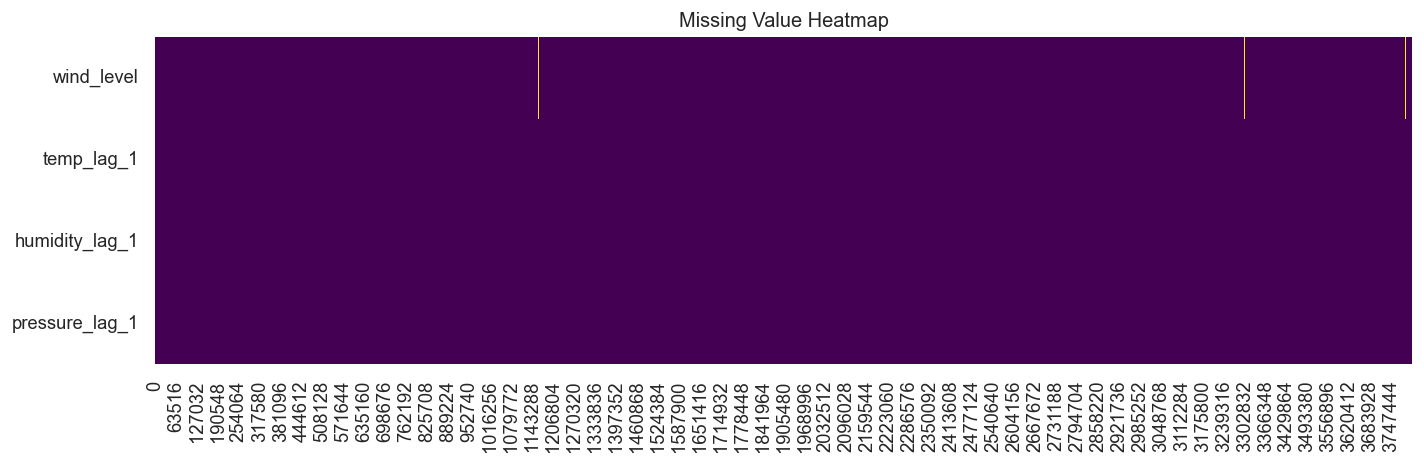

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing,
                           'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

if missing_df.empty:
    print('✅ Không có missing values sau preprocessing!')
else:
    print(missing_df)

    # Heatmap missing
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.heatmap(df[missing_df.index].isnull().T,
                cbar=False, yticklabels=True, ax=ax, cmap='viridis')
    ax.set_title('Missing Value Heatmap')
    plt.tight_layout()
    plt.show()

### 2.2 Duplicates

In [ ]:
dup_count = df.duplicated().sum()
print(f'Duplicate rows: {dup_count:,} ({dup_count/len(df)*100:.2f}%)')

Duplicate rows: 0 (0.00%)


### 2.3 Class imbalance – cột `extreme`

            count    pct
extreme                 
normal    3751765  98.45
heatwave    59148   1.55


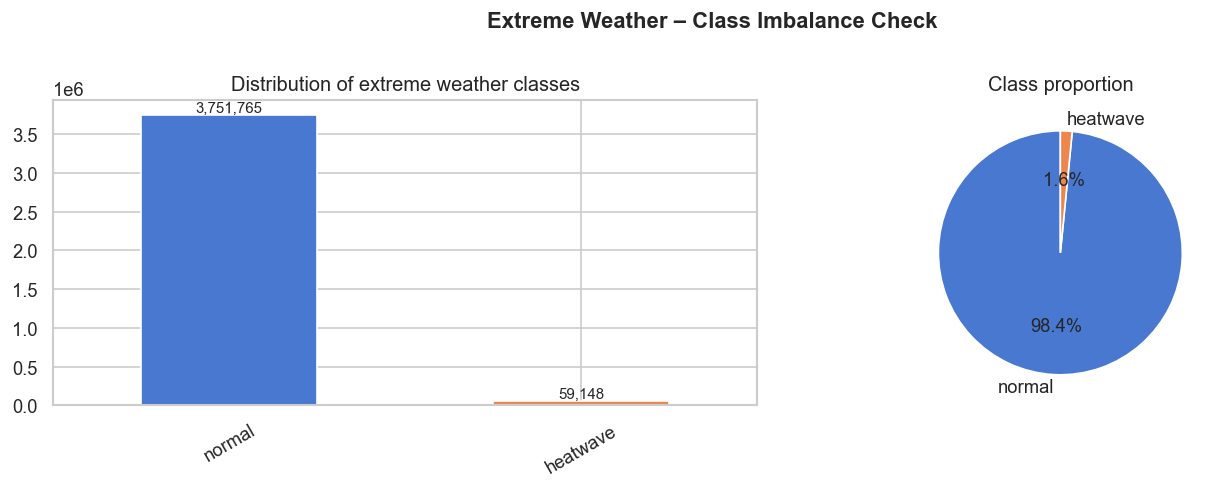

⚠️  Imbalance cao: class "normal" chiếm 98.45%
   → Cân nhắc SMOTE / class_weight khi train ML.


In [ ]:
if 'extreme' in df.columns:
    vc = df['extreme'].value_counts()
    vc_pct = (vc / len(df) * 100).round(2)
    print(pd.DataFrame({'count': vc, 'pct': vc_pct}))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Bar chart
    vc.plot(kind='bar', ax=axes[0], color=sns.color_palette('muted', len(vc)), edgecolor='white')
    axes[0].set_title('Distribution of extreme weather classes')
    axes[0].set_xlabel('')
    axes[0].tick_params(axis='x', rotation=30)
    for p in axes[0].patches:
        axes[0].annotate(f'{int(p.get_height()):,}',
                         (p.get_x() + p.get_width()/2, p.get_height()),
                         ha='center', va='bottom', fontsize=9)

    # Pie chart
    axes[1].pie(vc, labels=vc.index, autopct='%1.1f%%',
                colors=sns.color_palette('muted', len(vc)), startangle=90)
    axes[1].set_title('Class proportion')

    plt.suptitle('Extreme Weather – Class Imbalance Check', fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    # Cảnh báo imbalance
    majority_pct = vc_pct.max()
    if majority_pct > 70:
        print(f'⚠️  Imbalance cao: class "{vc.idxmax()}" chiếm {majority_pct}%')
        print('   → Cân nhắc SMOTE / class_weight khi train ML.')
    else:
        print('✅ Imbalance ở mức chấp nhận được.')

### 2.4 Kiểm tra outliers (IQR method)

In [ ]:
weather_num = [c for c in num_cols if not c.endswith(('_lag_1','_sin','_cos','_level'))
               and c not in ['hour','day','month','weekday','rain']]

outlier_report = []
for col in weather_num:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_report.append({'column': col, 'outliers': n_out,
                           'pct': round(n_out/len(df)*100, 2)})

outlier_df = pd.DataFrame(outlier_report).sort_values('pct', ascending=False)
print(outlier_df.to_string(index=False))

        column  outliers   pct
  weather_code    516179 13.54
 precipitation    511659 13.43
    visibility    320043  8.40
      pressure    237430  6.23
    cloudcover    224955  5.90
    wind_speed    129409  3.40
     wind_gust     40323  1.06
   temperature     35954  0.94
      temp_min     35342  0.93
      temp_max     35515  0.93
    temp_range     18716  0.49
      humidity     17462  0.46
    feels_like        48  0.00
wind_direction         0  0.00
        is_day         0  0.00


---
## 3. Thống Kê Mô Tả
### 3.1 Bảng describe

In [ ]:
df[weather_num].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
temperature,3810913.0,27.371,3.411,12.70,25.20,27.03,29.60,39.47
temp_min,3810913.0,27.349,3.406,12.70,25.17,27.01,29.58,39.47
temp_max,3810913.0,27.383,3.416,12.70,25.21,27.03,29.62,39.47
humidity,3810913.0,81.241,13.012,22.00,73.00,84.00,92.00,100.00
feels_like,3810913.0,30.345,5.514,12.35,26.01,30.28,34.84,46.01
visibility,3810913.0,9662.222,1336.382,1.00,10000.00,10000.00,10000.00,10000.00
precipitation,3810913.0,0.257,1.230,0.00,0.00,0.00,0.00,81.83
cloudcover,3810913.0,78.261,30.757,0.00,65.00,97.00,100.00,100.00
wind_speed,3810913.0,2.680,1.894,0.00,1.29,2.18,3.60,25.96
wind_gust,3810913.0,3.914,3.548,0.00,1.12,2.79,6.15,34.30


### 3.2 Phân phối các biến số (histograms + KDE)

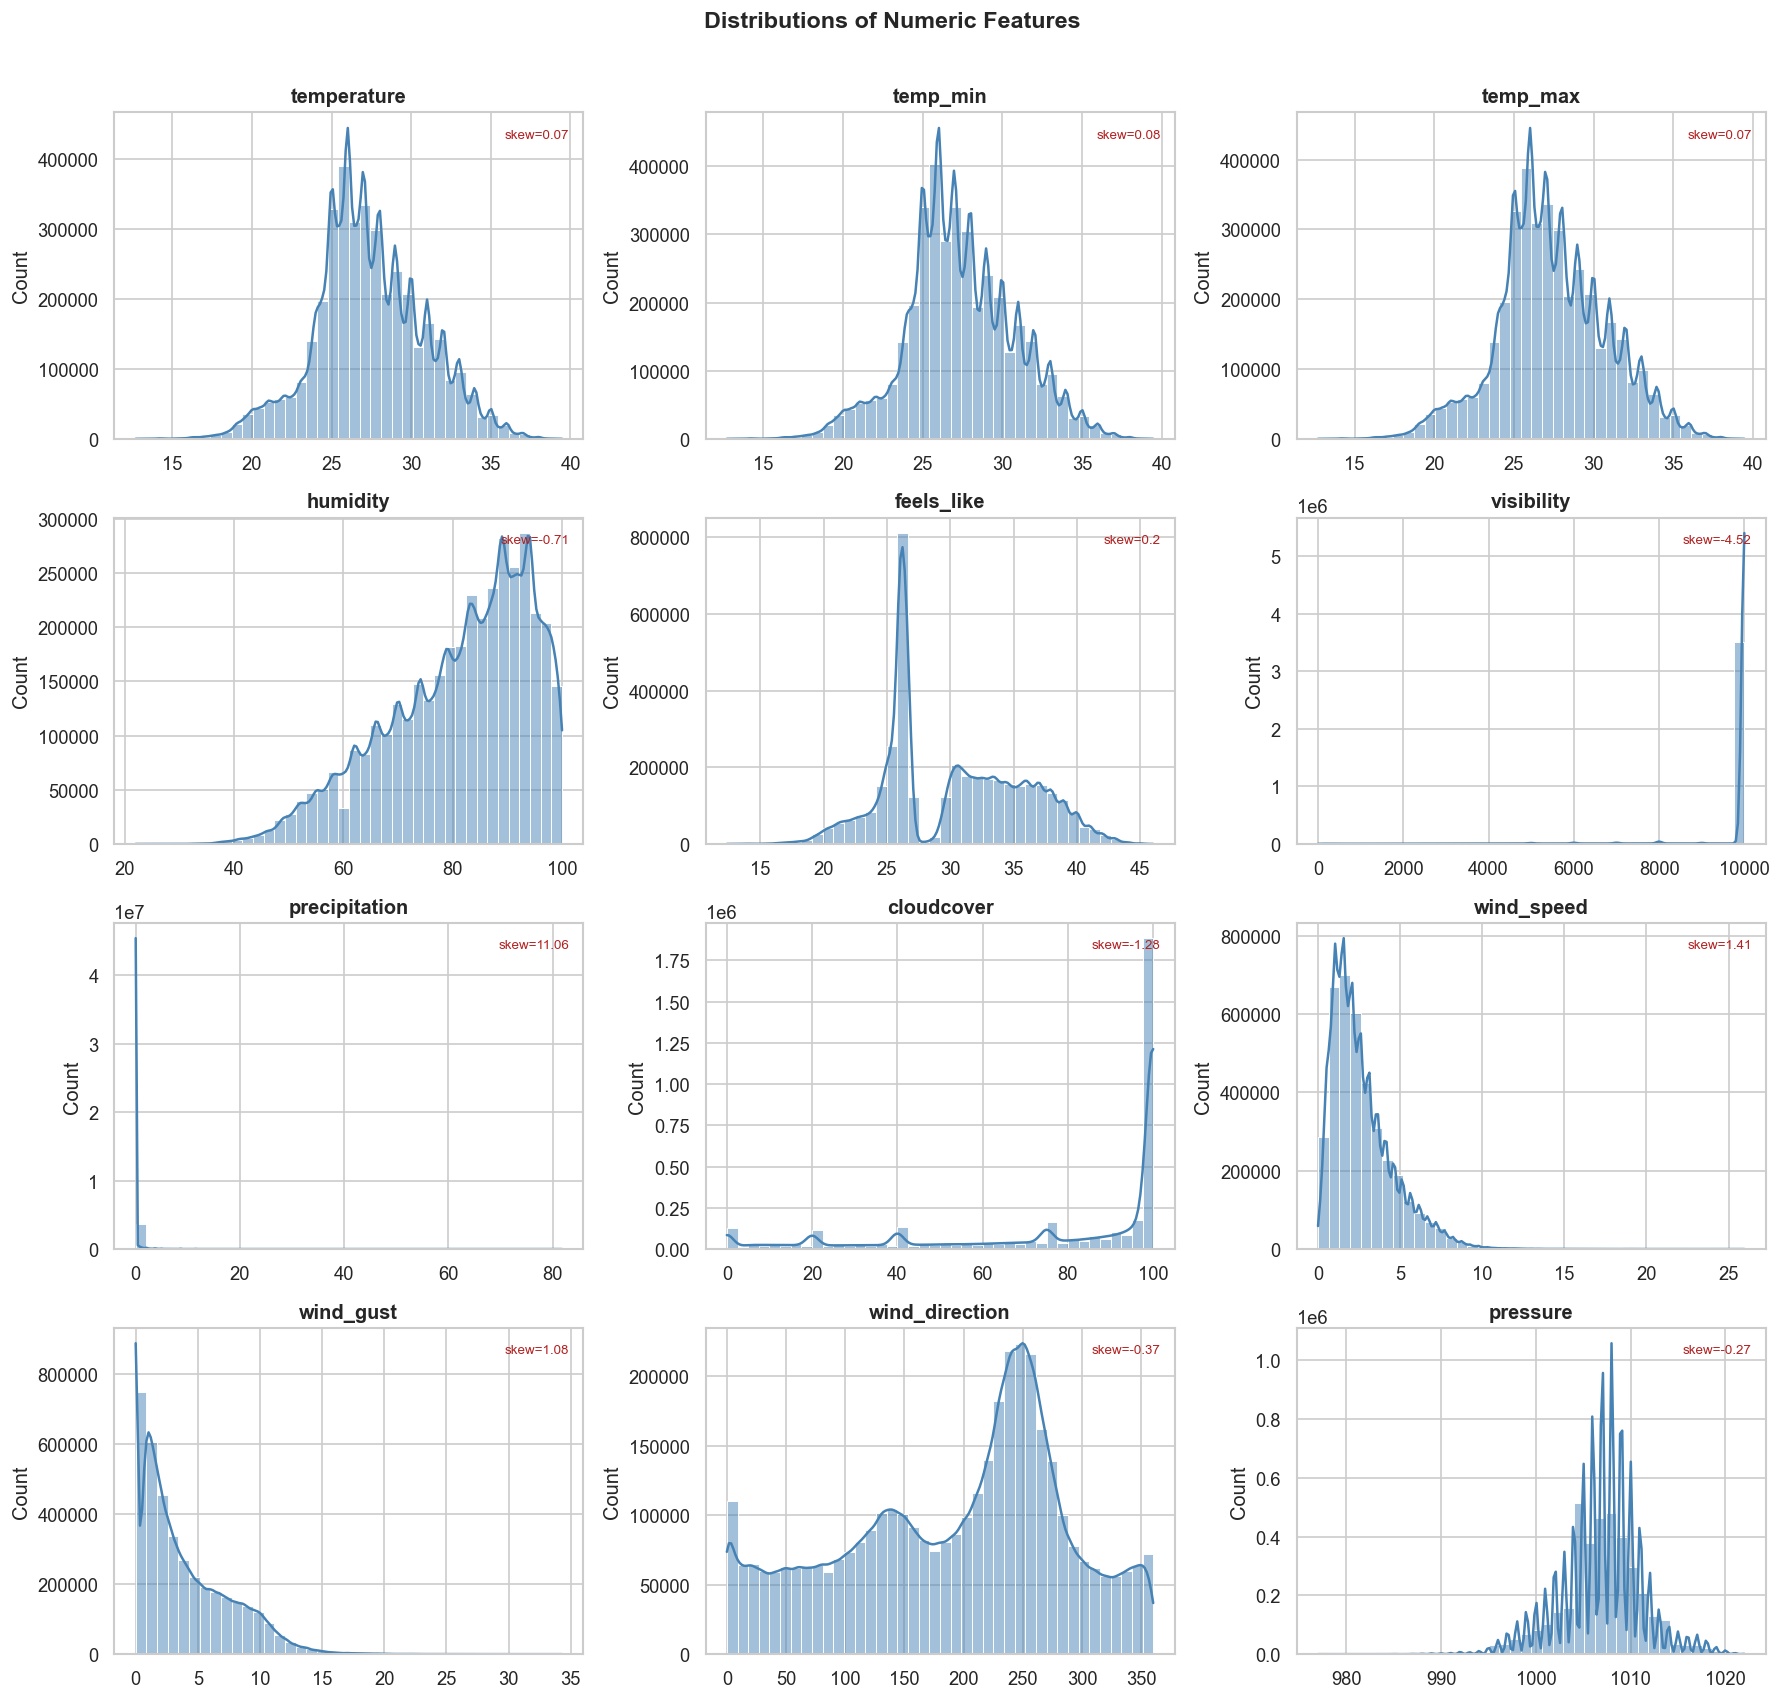

In [ ]:
cols_to_plot = weather_num[:12]  # tối đa 12 biến
n = len(cols_to_plot)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    data = df[col].dropna()
    sns.histplot(data, kde=True, ax=ax, color='steelblue', edgecolor='white', bins=40)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    # Skewness
    skew = round(data.skew(), 2)
    ax.text(0.97, 0.95, f'skew={skew}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='firebrick')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions of Numeric Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Boxplots – phát hiện outliers trực quan

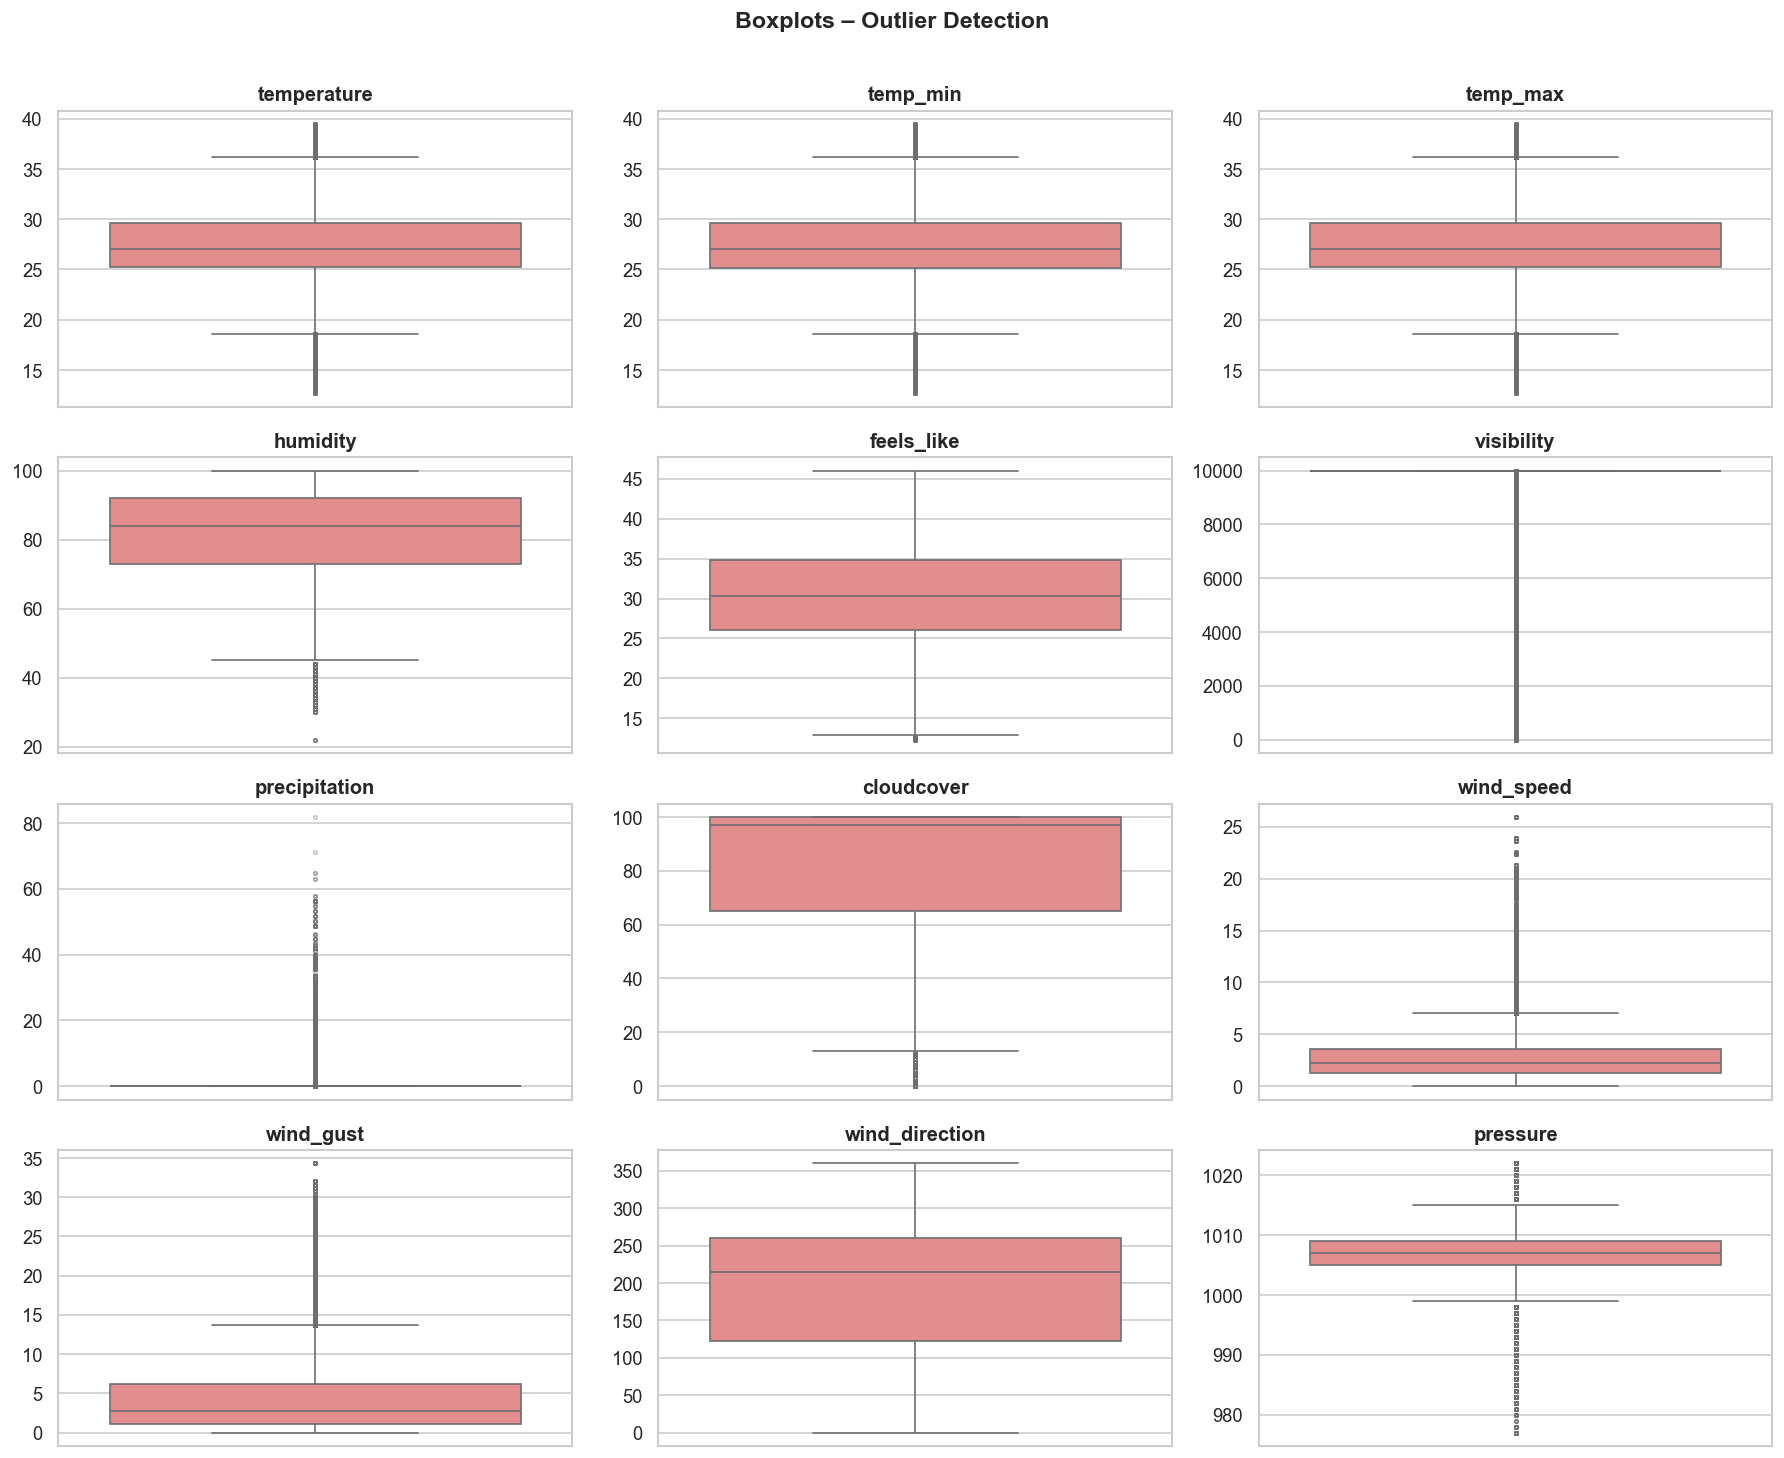

In [ ]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    sns.boxplot(y=df[col].dropna(), ax=ax, color='lightcoral',
                flierprops=dict(marker='o', markersize=2, alpha=0.4))
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots – Outlier Detection', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.4 Correlation heatmap

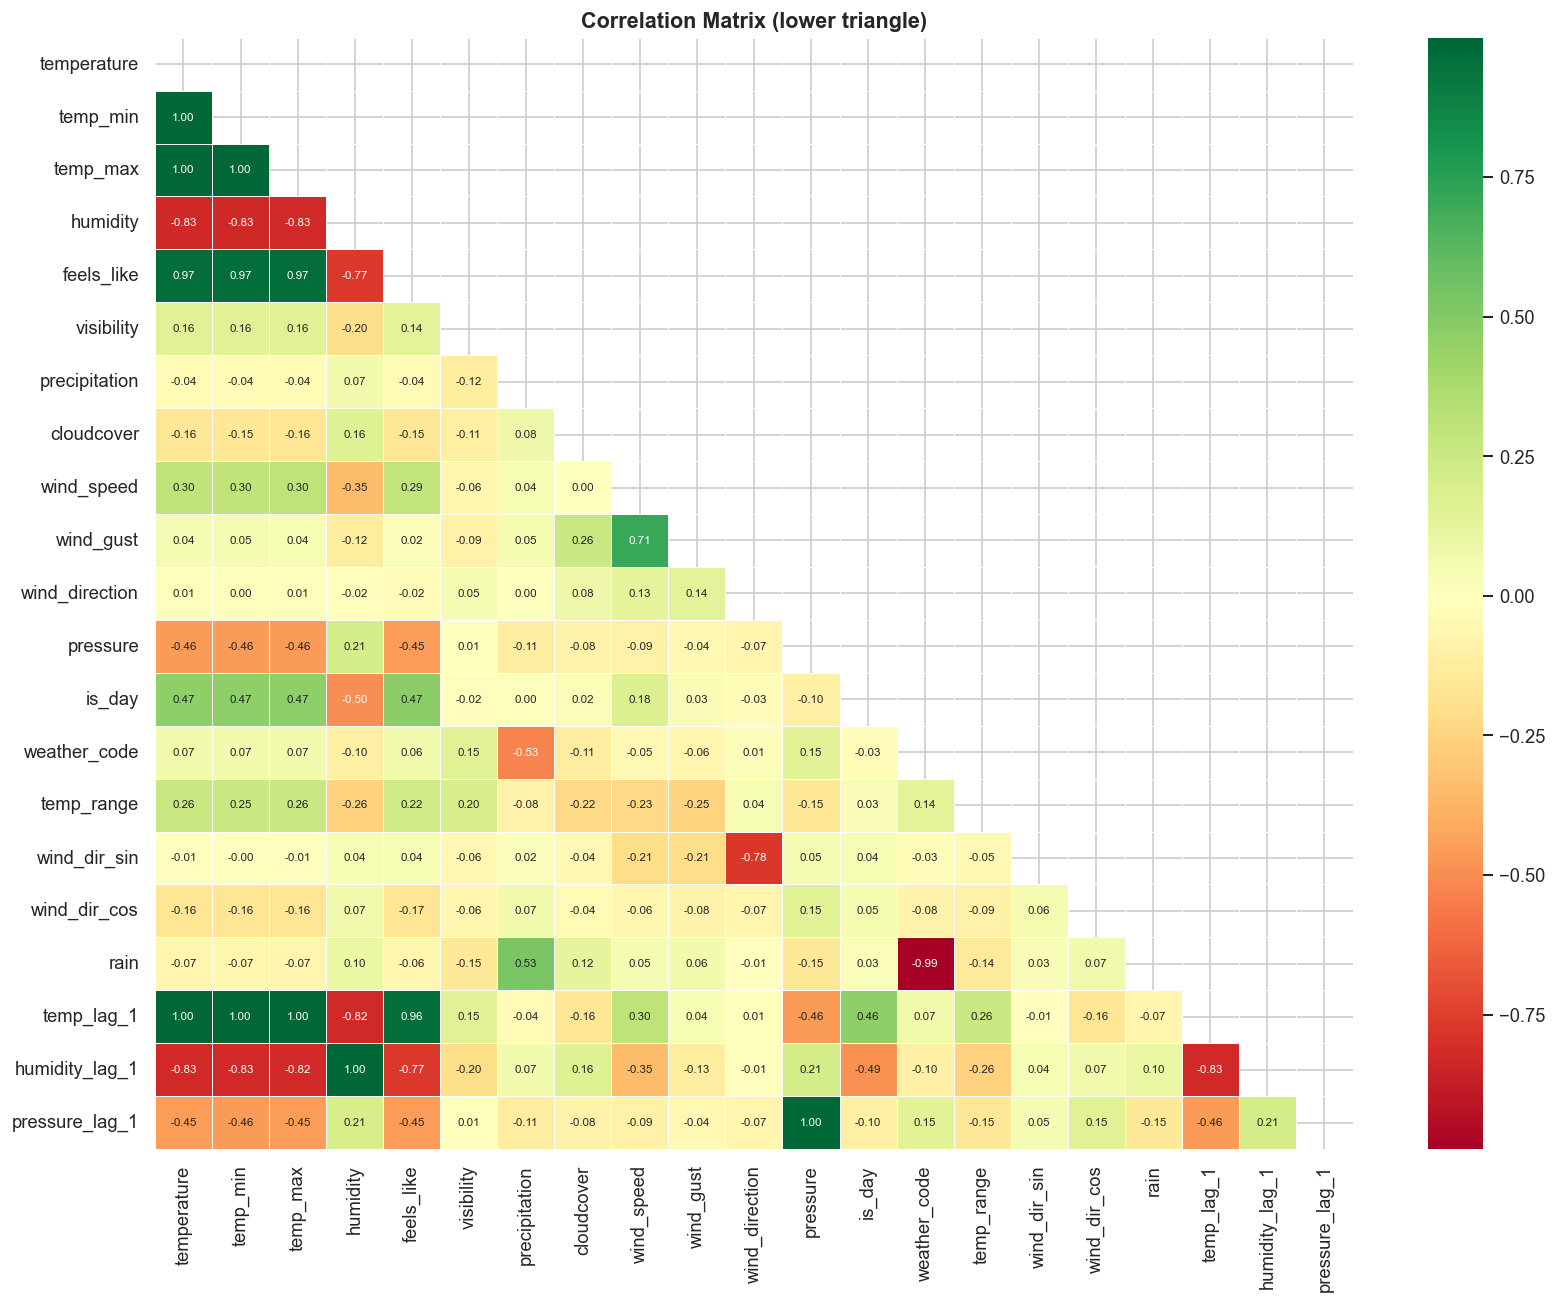


--- Top correlations with numeric proxy of extreme ---
temp_min          0.316
temperature       0.315
temp_max          0.314
temp_lag_1        0.313
humidity          0.307
humidity_lag_1    0.306
feels_like        0.261
pressure          0.180
pressure_lag_1    0.178
temp_range        0.153
Name: extreme_num, dtype: float64


In [ ]:
corr_cols = [c for c in num_cols if c not in ['hour','day','month','weekday']]
corr_matrix = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.3,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Correlation Matrix (lower triangle)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations với target (nếu có)
if 'extreme' in df.columns:
    print('\n--- Top correlations with numeric proxy of extreme ---')
    extreme_map = {'normal':0,'storm':1,'heavy_rain':2,'heatwave':3}
    df['extreme_num'] = df['extreme'].map(extreme_map)
    target_corr = df[corr_cols + ['extreme_num']].corr()['extreme_num'].drop('extreme_num')
    print(target_corr.abs().sort_values(ascending=False).head(10).round(3))

---
## 4. So Sánh Giữa Các Tỉnh/Thành Phố
> *Lưu ý: preprocessing đã drop cột `city`/`province` sau khi tạo lag features.*  
> *Cell này chạy nếu bạn load dữ liệu còn giữ cột đó, hoặc join lại từ raw.*

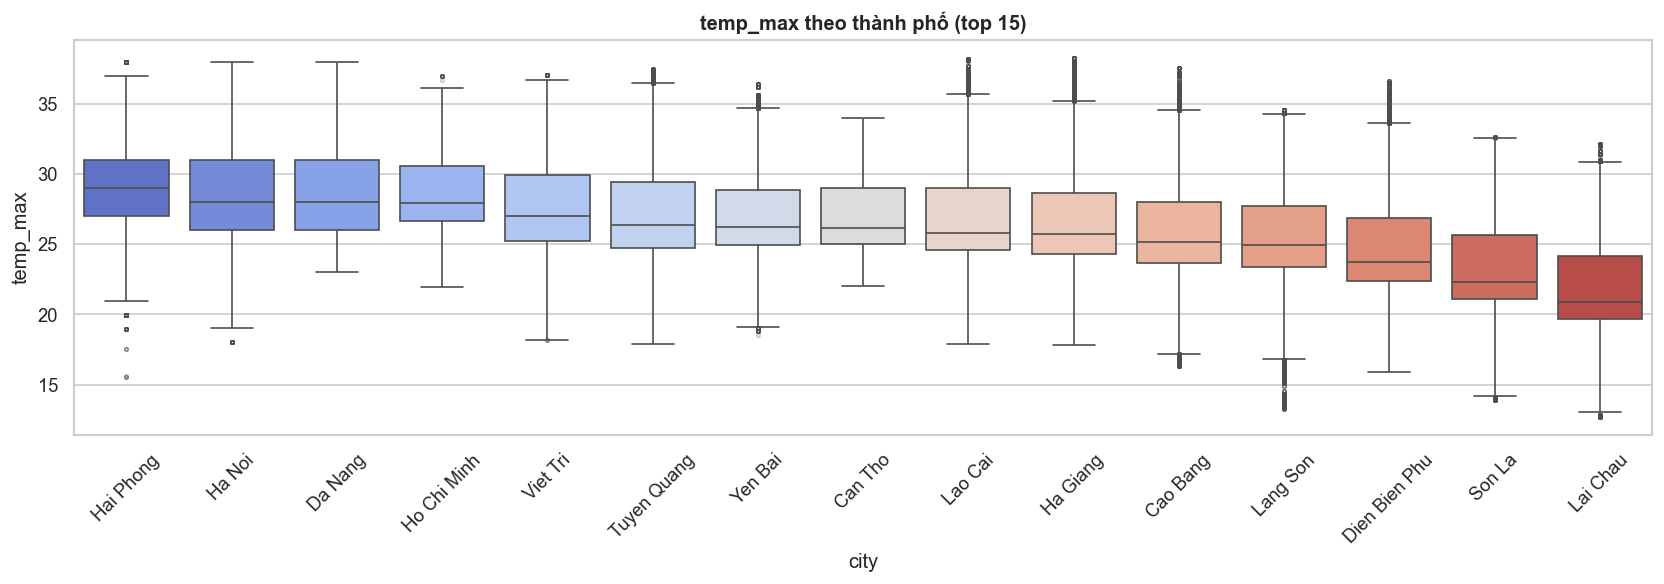

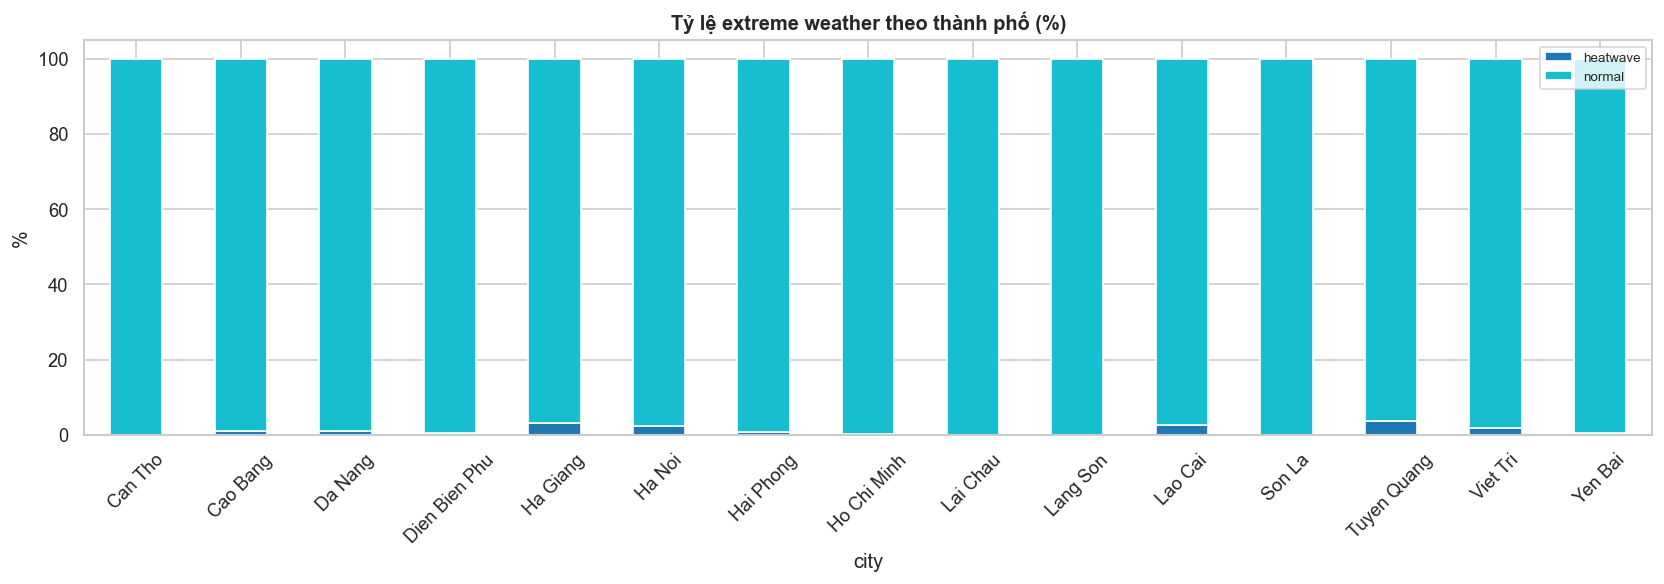


=== Thống kê theo thành phố ===


In [ ]:
city_col = next((c for c in ['city','province','location'] if c in df.columns), None)

if city_col is None:
    print('⚠️  Không tìm thấy cột city/province trong cleaned file.')
    print('   Preprocessing đã drop cột này (step 8).')
    print('   → Khuyến nghị: thêm city vào danh sách giữ lại trong preprocessing.py')
    print('   → Hoặc join lại từ raw file để phân tích theo vùng.')
else:
    top_cities = df[city_col].value_counts().head(15).index
    df_top = df[df[city_col].isin(top_cities)]

    temp_col = next((c for c in ['temp_max','temperature','temp'] if c in df.columns), None)

    if temp_col:
        # Boxplot nhiệt độ theo thành phố
        fig, ax = plt.subplots(figsize=(14, 5))
        order = df_top.groupby(city_col)[temp_col].median().sort_values(ascending=False).index
        sns.boxplot(data=df_top, x=city_col, y=temp_col, order=order,
                    palette='coolwarm', ax=ax,
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))
        ax.set_title(f'{temp_col} theo thành phố (top {len(top_cities)})', fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()

    # So sánh extreme class theo city
    if 'extreme' in df.columns:
        fig, ax = plt.subplots(figsize=(14, 5))
        city_extreme = df_top.groupby([city_col, 'extreme']).size().unstack(fill_value=0)
        city_extreme_pct = city_extreme.div(city_extreme.sum(axis=1), axis=0) * 100
        city_extreme_pct.plot(kind='bar', stacked=True,
                               colormap='tab10', edgecolor='white', ax=ax)
        ax.set_title('Tỷ lệ extreme weather theo thành phố (%)', fontweight='bold')
        ax.set_ylabel('%')
        ax.tick_params(axis='x', rotation=45)
        ax.legend(loc='upper right', fontsize=8)
        plt.tight_layout()
        plt.show()

    # Thống kê tổng hợp theo thành phố
    agg_cols = [c for c in ['temp_max','temp_min','humidity','pressure','wind_speed','rainfall'] if c in df.columns]
    city_stats = df_top.groupby(city_col)[agg_cols].agg(['mean','std']).round(2)
    print('\n=== Thống kê theo thành phố ===')
    city_stats

---
## 5. Phân Tích Theo Thời Gian
### 5.1 Trend – nhiệt độ trung bình theo tháng

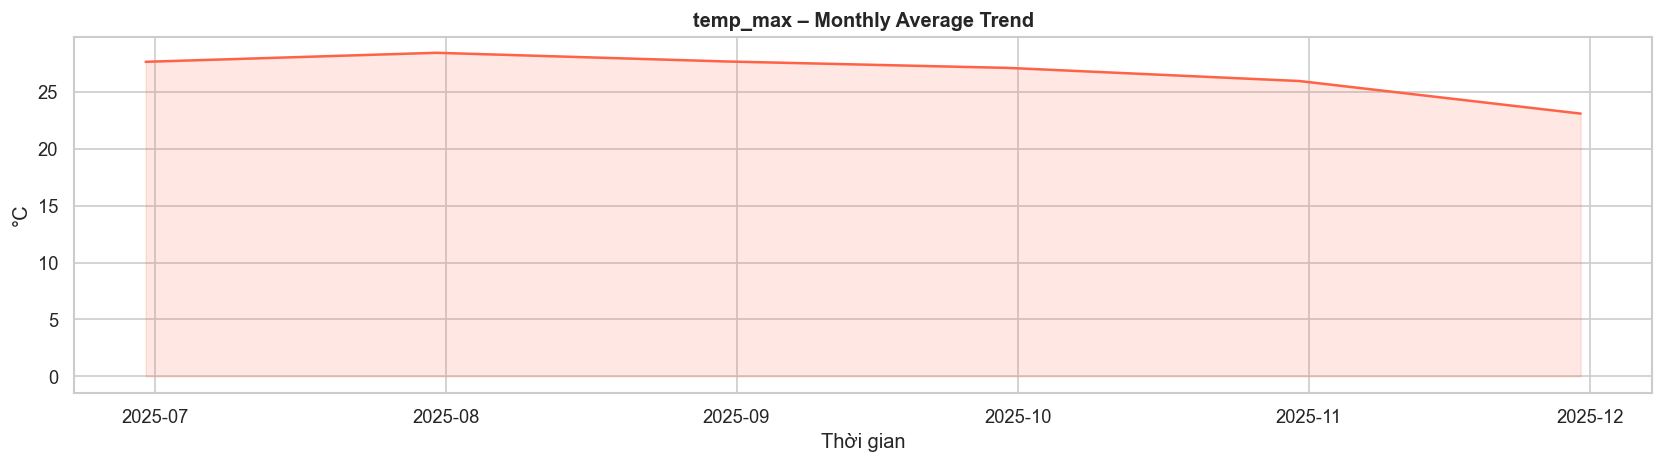

In [ ]:
temp_col = next((c for c in ['temp_max','temperature','temp'] if c in df.columns), None)

if temp_col and 'time' in df.columns:
    monthly = df.set_index('time')[temp_col].resample('ME').mean()

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(monthly.index, monthly.values, color='tomato', linewidth=1.5)
    ax.fill_between(monthly.index, monthly.values, alpha=0.15, color='tomato')
    ax.set_title(f'{temp_col} – Monthly Average Trend', fontweight='bold')
    ax.set_xlabel('Thời gian')
    ax.set_ylabel('°C')
    plt.tight_layout()
    plt.show()

### 5.2 Seasonality – phân phối theo tháng (boxplot)

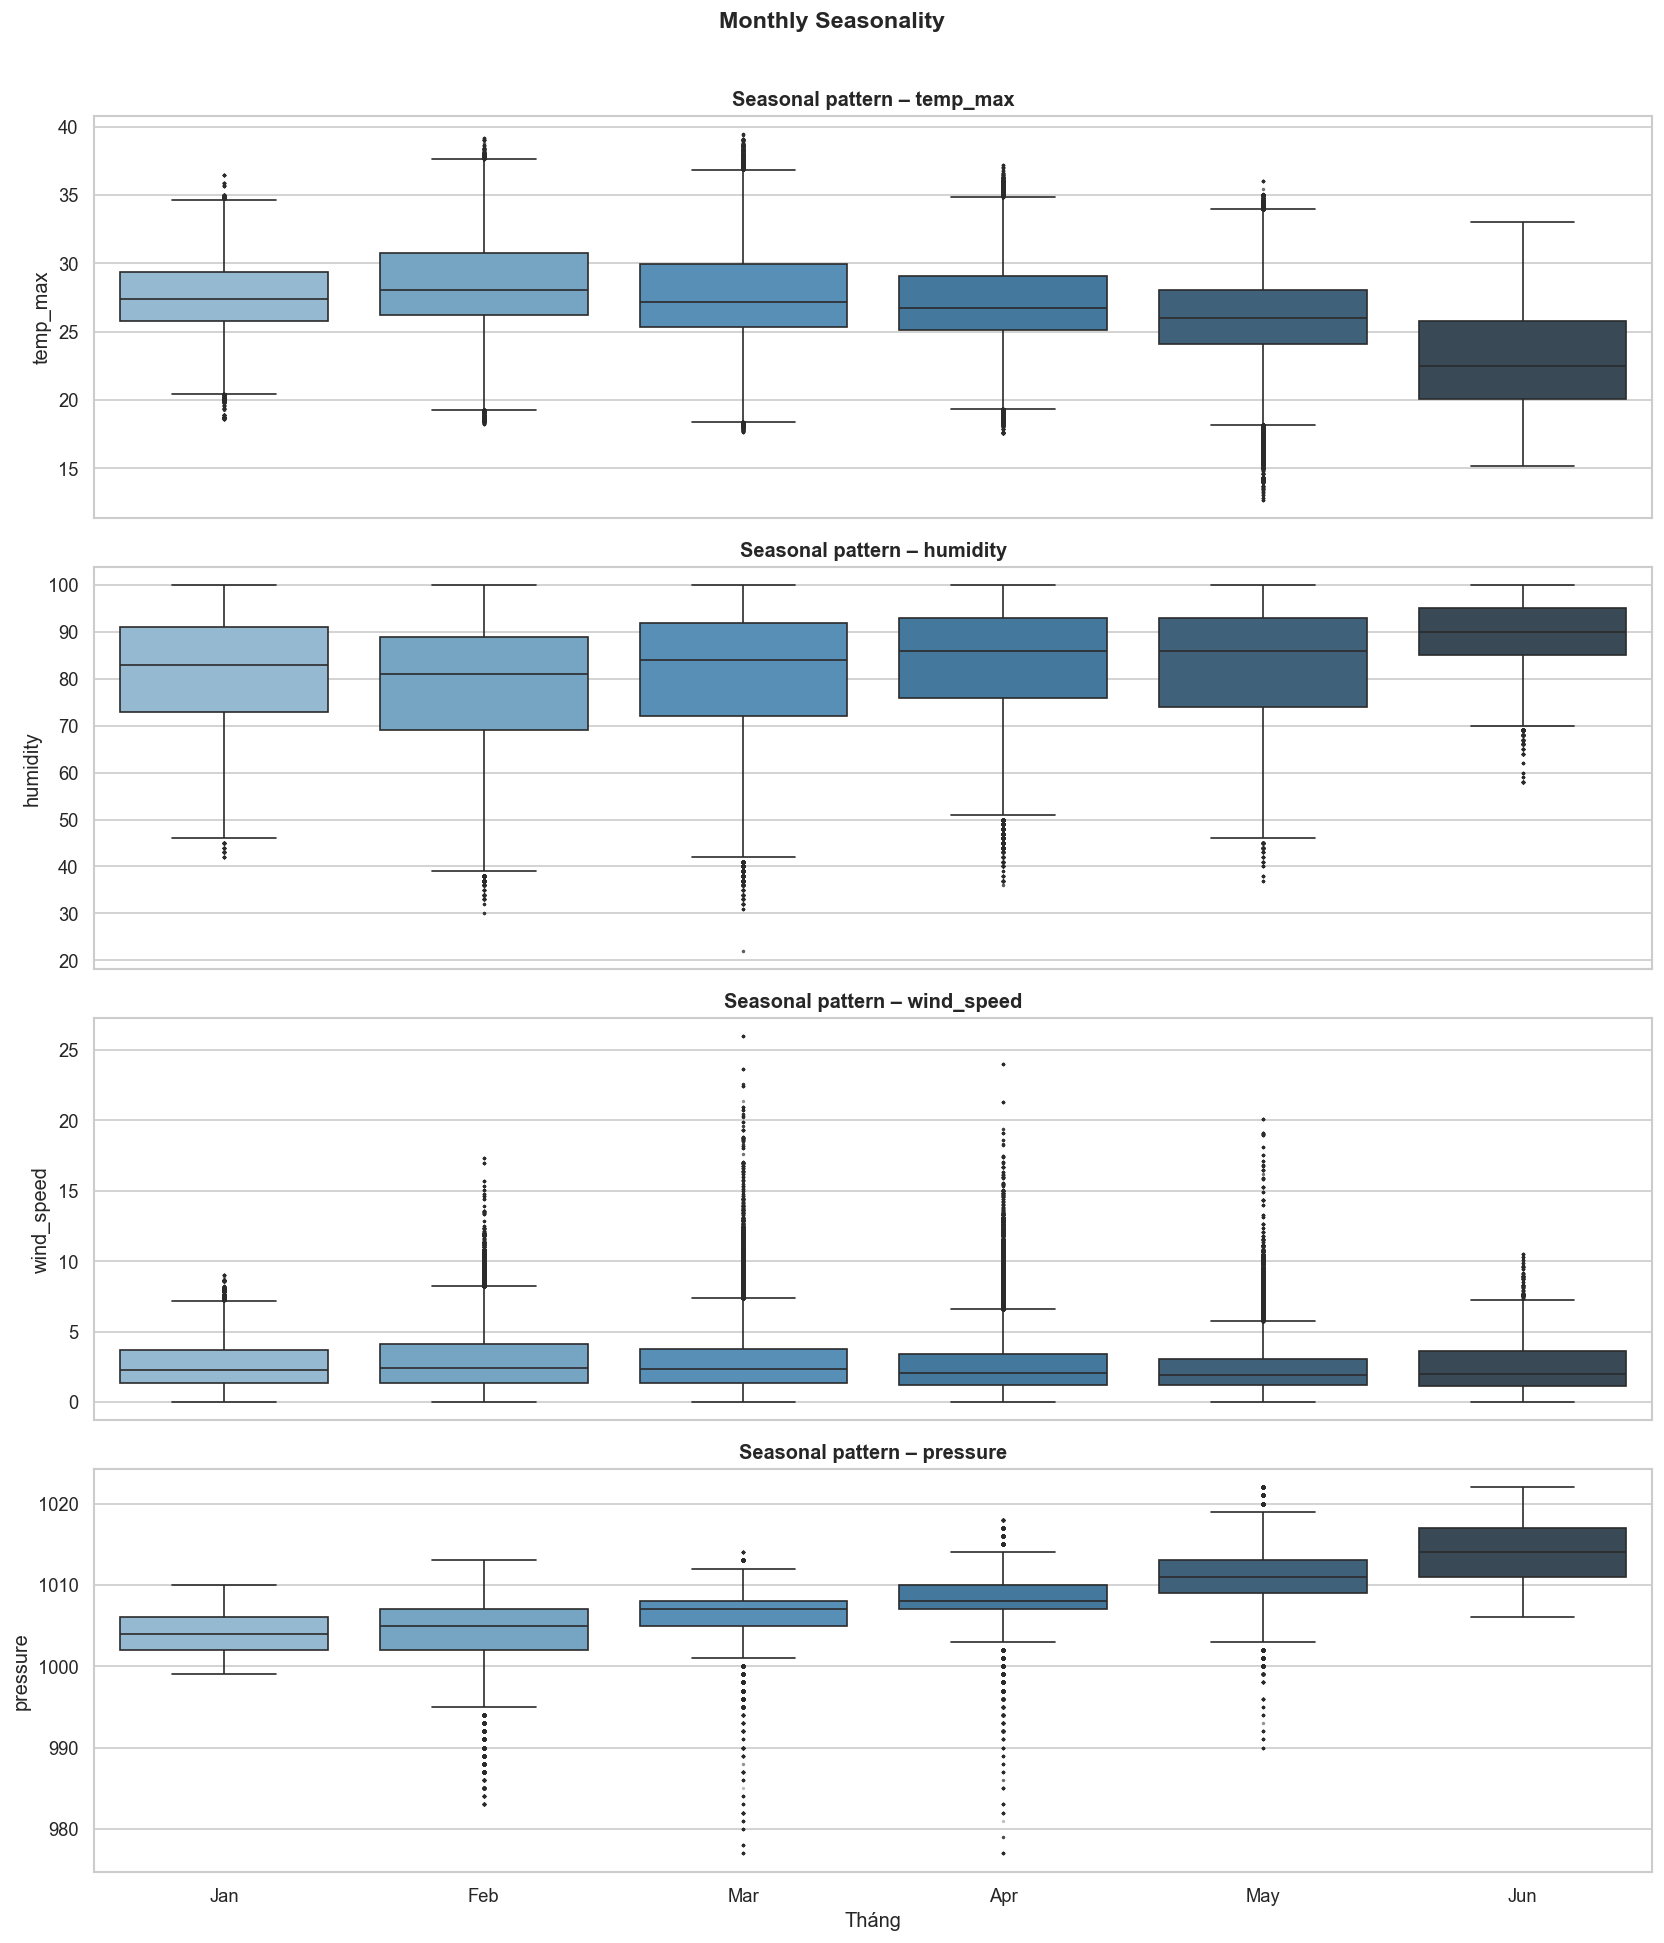

In [ ]:
season_vars = [c for c in ['temp_max','humidity','rainfall','wind_speed','pressure'] if c in df.columns]

if 'month' in df.columns and season_vars:
    fig, axes = plt.subplots(len(season_vars), 1,
                              figsize=(14, 4 * len(season_vars)), sharex=True)
    if len(season_vars) == 1:
        axes = [axes]

    month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec']

    for ax, col in zip(axes, season_vars):
        sns.boxplot(data=df, x='month', y=col, ax=ax,
                    palette='Blues_d',
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
        ax.set_title(f'Seasonal pattern – {col}', fontweight='bold')
        ax.set_xticklabels(month_labels)
        ax.set_xlabel('')

    axes[-1].set_xlabel('Tháng')
    plt.suptitle('Monthly Seasonality', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

### 5.3 Intra-day pattern – theo giờ trong ngày

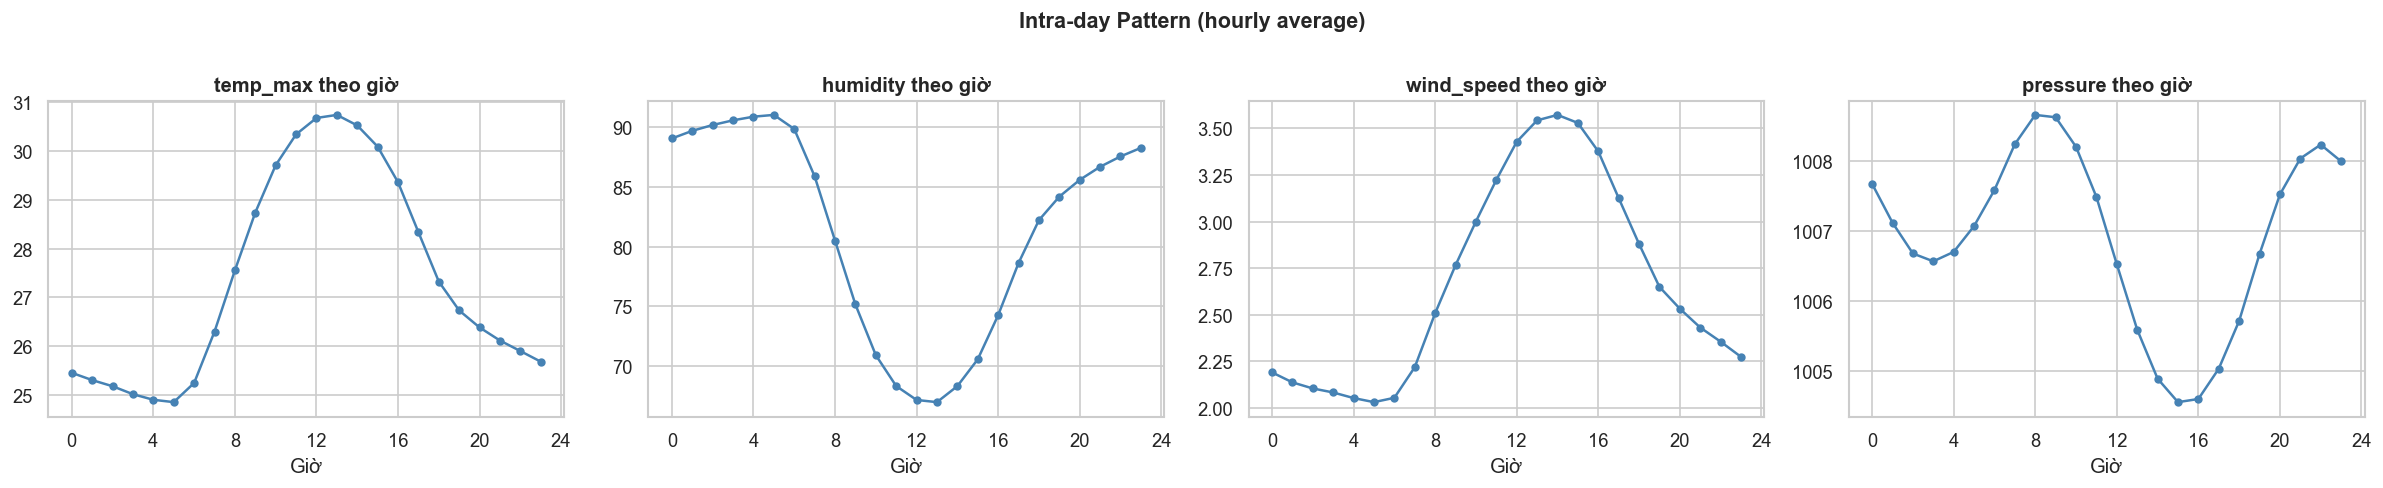

In [ ]:
if 'hour' in df.columns and season_vars:
    hourly = df.groupby('hour')[season_vars].mean()

    fig, axes = plt.subplots(1, len(season_vars), figsize=(5 * len(season_vars), 4))
    if len(season_vars) == 1:
        axes = [axes]

    for ax, col in zip(axes, season_vars):
        ax.plot(hourly.index, hourly[col], marker='o', markersize=4,
                color='steelblue', linewidth=1.5)
        ax.set_title(f'{col} theo giờ', fontweight='bold')
        ax.set_xlabel('Giờ')
        ax.xaxis.set_major_locator(mticker.MultipleLocator(4))

    plt.suptitle('Intra-day Pattern (hourly average)', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

### 5.4 Heatmap – nhiệt độ trung bình theo (tháng × giờ)

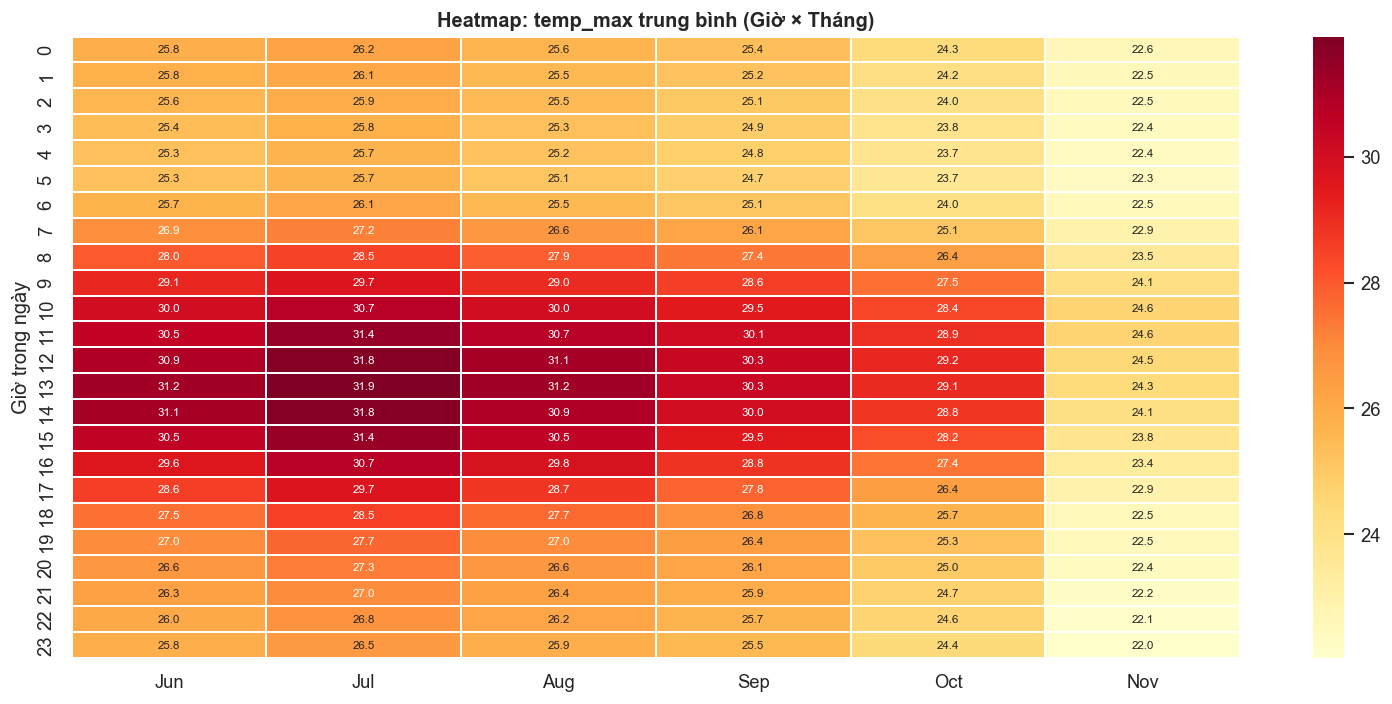

In [ ]:
if temp_col and 'month' in df.columns and 'hour' in df.columns:
    pivot = df.pivot_table(values=temp_col, index='hour', columns='month', aggfunc='mean')
    pivot.columns = ['Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec'][:len(pivot.columns)]

    fig, ax = plt.subplots(figsize=(13, 6))
    sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.1f',
                linewidths=0.2, annot_kws={'size': 7}, ax=ax)
    ax.set_title(f'Heatmap: {temp_col} trung bình (Giờ × Tháng)', fontweight='bold')
    ax.set_ylabel('Giờ trong ngày')
    plt.tight_layout()
    plt.show()

### 5.5 Trend số lượng extreme events theo tháng

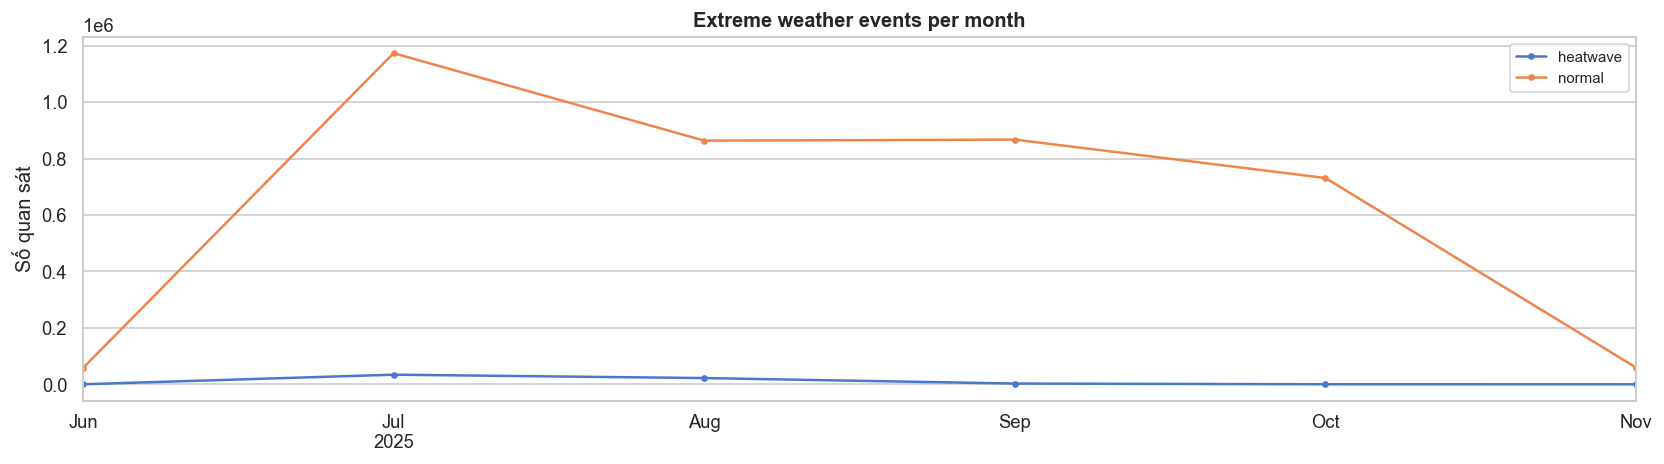

In [ ]:
if 'extreme' in df.columns and 'time' in df.columns:
    df_ext = df.set_index('time')
    classes = df['extreme'].unique()
    monthly_ext = df_ext.groupby([pd.Grouper(freq='ME'), 'extreme']).size().unstack(fill_value=0)

    fig, ax = plt.subplots(figsize=(14, 4))
    monthly_ext.plot(ax=ax, linewidth=1.5, marker='o', markersize=3)
    ax.set_title('Extreme weather events per month', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Số quan sát')
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()

---
## 6. Feature Engineering – Kiểm Tra Kết Quả Preprocessing
### 6.1 Lag features

In [ ]:
lag_cols = [c for c in df.columns if '_lag_' in c]
print('Lag features:', lag_cols)

if lag_cols and temp_col:
    orig = temp_col
    lag  = f'{temp_col}_lag_1'
    if lag in df.columns:
        sample = df[[orig, lag]].dropna().sample(min(3000, len(df)), random_state=42)

        fig, ax = plt.subplots(figsize=(7, 5))
        ax.scatter(sample[lag], sample[orig], alpha=0.2, s=8, color='steelblue')
        ax.set_xlabel(f'{lag} (t-1)')
        ax.set_ylabel(f'{orig} (t)')
        ax.set_title(f'Autocorrelation: {orig} vs {lag}', fontweight='bold')
        r, p = stats.pearsonr(sample[lag], sample[orig])
        ax.text(0.05, 0.95, f'r = {r:.3f}  (p < 0.001)',
                transform=ax.transAxes, va='top')
        plt.tight_layout()
        plt.show()

Lag features: ['temp_lag_1', 'humidity_lag_1', 'pressure_lag_1']


### 6.2 Discretized level columns

Level columns: ['temp_level', 'humidity_level', 'pressure_level', 'wind_level']


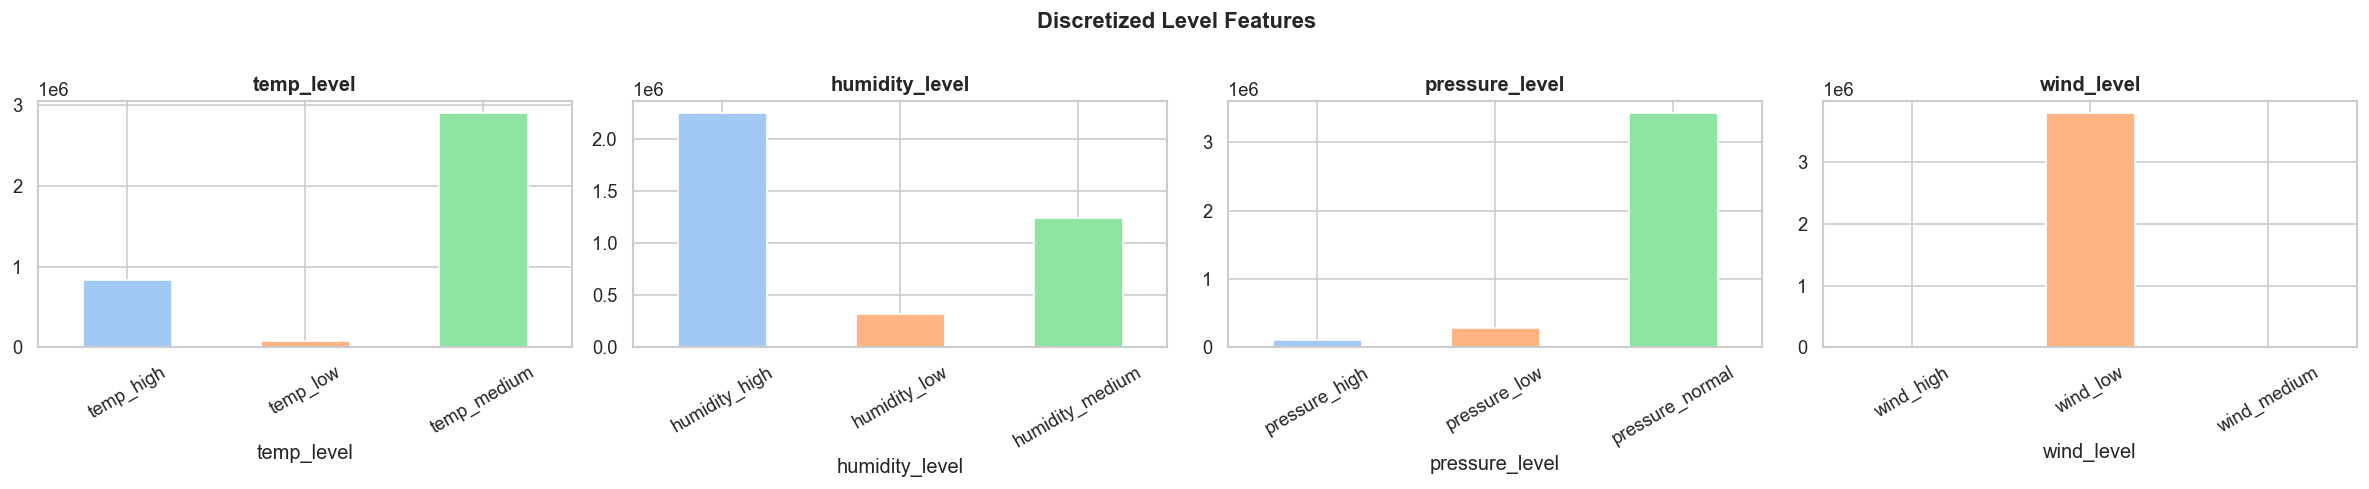

In [ ]:
level_cols = [c for c in df.columns if c.endswith('_level')]
print('Level columns:', level_cols)

if level_cols:
    n = len(level_cols)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1: axes = [axes]

    for ax, col in zip(axes, level_cols):
        vc = df[col].value_counts().sort_index()
        vc.plot(kind='bar', ax=ax, color=sns.color_palette('pastel'), edgecolor='white')
        ax.set_title(col, fontweight='bold')
        ax.tick_params(axis='x', rotation=30)

    plt.suptitle('Discretized Level Features', fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

### 6.3 Wind direction – sin/cos encoding

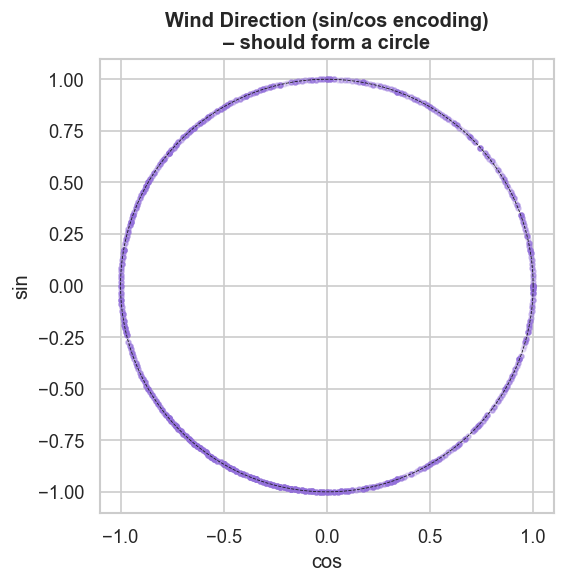

In [ ]:
if 'wind_dir_sin' in df.columns and 'wind_dir_cos' in df.columns:
    sample_wind = df[['wind_dir_sin','wind_dir_cos']].dropna().sample(
        min(2000, len(df)), random_state=1)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(sample_wind['wind_dir_cos'], sample_wind['wind_dir_sin'],
               alpha=0.2, s=8, color='mediumpurple')
    theta = np.linspace(0, 2*np.pi, 300)
    ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=0.5)
    ax.set_aspect('equal')
    ax.set_title('Wind Direction (sin/cos encoding)\n– should form a circle', fontweight='bold')
    ax.set_xlabel('cos')
    ax.set_ylabel('sin')
    plt.tight_layout()
    plt.show()

---
## 7. Insights & Gợi Ý Cho ML

In [ ]:
print('=' * 60)
print('TỔNG KẾT EDA – GỢI Ý CHO ML PIPELINE')
print('=' * 60)

# 1. Shape
print(f'\n📦 Dataset: {df.shape[0]:,} rows × {df.shape[1]} features')

# 2. Missing
total_missing = df.isnull().sum().sum()
print(f'\n🔍 Missing values còn lại: {total_missing}')
if total_missing > 0:
    print('   → Cần xử lý trước khi train (impute hoặc drop)')
else:
    print('   ✅ Sạch hoàn toàn')

# 3. Lag features có NaN đầu chuỗi
if lag_cols:
    lag_nan = df[lag_cols].isnull().sum().sum()
    print(f'\n⏳ NaN trong lag features: {lag_nan}')
    print('   → Do shift(1) – nên dropna() trước khi train ML')

# 4. Imbalance
if 'extreme' in df.columns:
    vc = df['extreme'].value_counts(normalize=True) * 100
    print(f'\n⚖️  Class distribution (extreme):')
    for cls, pct in vc.items():
        print(f'   {cls:<15}: {pct:.1f}%')
    if vc.max() > 70:
        print('   ⚠️  Imbalance đáng kể → dùng SMOTE / class_weight / F1-macro')

# 5. Feature suggestions
print('\n💡 Feature recommendations:')
if level_cols:
    print(f'   - {len(level_cols)} level cols có thể dùng cho Apriori')
if lag_cols:
    print(f'   - {len(lag_cols)} lag features → phù hợp time-series ML')
if 'wind_dir_sin' in df.columns:
    print('   - wind_dir_sin/cos: cyclic encoding ✅')
if 'temp_range' in df.columns:
    print('   - temp_range: derived feature ✅')
if 'rain' in df.columns:
    print('   - rain (binary): có thể dùng làm binary classification target')

print('\n🚀 Gợi ý bước tiếp theo:')
print('   1. dropna() cho lag features trước train/test split')
print('   2. TimeSeriesSplit thay vì random split (data có temporal dependency)')
print('   3. Scale numeric features (StandardScaler hoặc RobustScaler vì có outliers)')
print('   4. Encode categorical với OrdinalEncoder (level cols) hoặc LabelEncoder')
print('   5. Nếu target là extreme: dùng F1-macro / ROC-AUC đa lớp để đánh giá')
print('=' * 60)

TỔNG KẾT EDA – GỢI Ý CHO ML PIPELINE

📦 Dataset: 3,810,913 rows × 37 features

🔍 Missing values còn lại: 9473
   → Cần xử lý trước khi train (impute hoặc drop)

⏳ NaN trong lag features: 234
   → Do shift(1) – nên dropna() trước khi train ML

⚖️  Class distribution (extreme):
   normal         : 98.4%
   heatwave       : 1.6%
   ⚠️  Imbalance đáng kể → dùng SMOTE / class_weight / F1-macro

💡 Feature recommendations:
   - 4 level cols có thể dùng cho Apriori
   - 3 lag features → phù hợp time-series ML
   - wind_dir_sin/cos: cyclic encoding ✅
   - temp_range: derived feature ✅
   - rain (binary): có thể dùng làm binary classification target

🚀 Gợi ý bước tiếp theo:
   1. dropna() cho lag features trước train/test split
   2. TimeSeriesSplit thay vì random split (data có temporal dependency)
   3. Scale numeric features (StandardScaler hoặc RobustScaler vì có outliers)
   4. Encode categorical với OrdinalEncoder (level cols) hoặc LabelEncoder
   5. Nếu target là extreme: dùng F1-macro / 